In [20]:
import os
os.chdir('credit-risk-prediction')

In [22]:
from google.colab import files

#opens a file picker to select the dataset
uploaded = files.upload()

#moves it into data/ repo
import shutil
shutil.move('german_credit_data.csv', 'data/german_credit_data.csv')
print('Dataset is at data/')


Saving german_credit_data.csv to german_credit_data.csv
Dataset is at data/


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#sklearn preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#sklearn models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

#sklearn evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)

#Imbalanced Data
from imblearn.over_sampling import SMOTE

#Project Config from vscode src/
import sys
sys.path.append('src')
from config import *

print('All libraries imported!')

All libraries imported!


#  Exploratory Data Analysis


In [24]:
df = pd.read_csv('data/german_credit_data.csv', index_col=0)

print(f'Shape: {df.shape}')
print(f'\nColumn types:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nTarget distribution:\n{df[TARGET_COL].value_counts()}')

df.head()


Shape: (1000, 10)

Column types:
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

Missing values:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

Target distribution:
Risk
good    700
bad     300
Name: count, dtype: int64


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


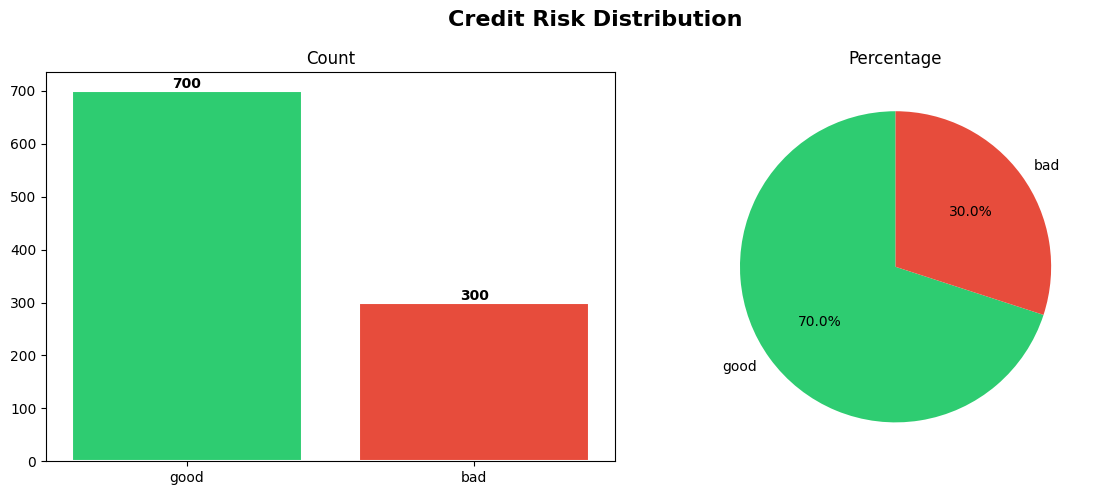

In [25]:
fig, axes = plt.subplots(1, 2,figsize=(12, 5))
fig.suptitle('Credit Risk Distribution',fontsize=16,fontweight='bold')

risk_counts = df[TARGET_COL].value_counts()

axes[0].bar(risk_counts.index, risk_counts.values,color=['#2ecc71','#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Count')
for i, v in enumerate(risk_counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

axes[1].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'], startangle=90)
axes[1].set_title('Percentage')

plt.tight_layout()
plt.savefig('outputs/plots/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


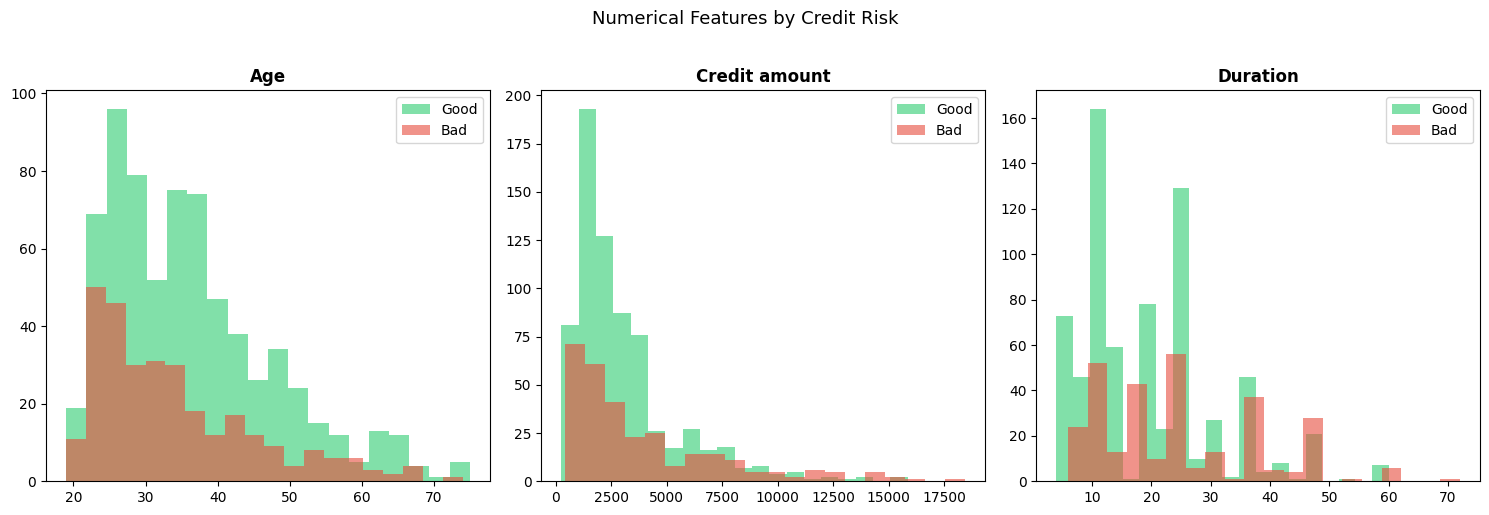

In [26]:
#numerical distributions by risk
fig, axes = plt.subplots(1, len(NUMERICAL_FEATURES), figsize=(5*len(NUMERICAL_FEATURES), 5))
if len(NUMERICAL_FEATURES) == 1: axes = [axes]

for ax, col in zip(axes, NUMERICAL_FEATURES):
    for risk, color in zip(['good','bad'], ['#2ecc71','#e74c3c']):
        data = df[df[TARGET_COL].str.lower()==risk][col]
        ax.hist(data, alpha=0.6, label=risk.capitalize(), bins=20, color=color)
    ax.set_title(col, fontweight='bold')
    ax.legend()

plt.suptitle('Numerical Features by Credit Risk', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('outputs/plots/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


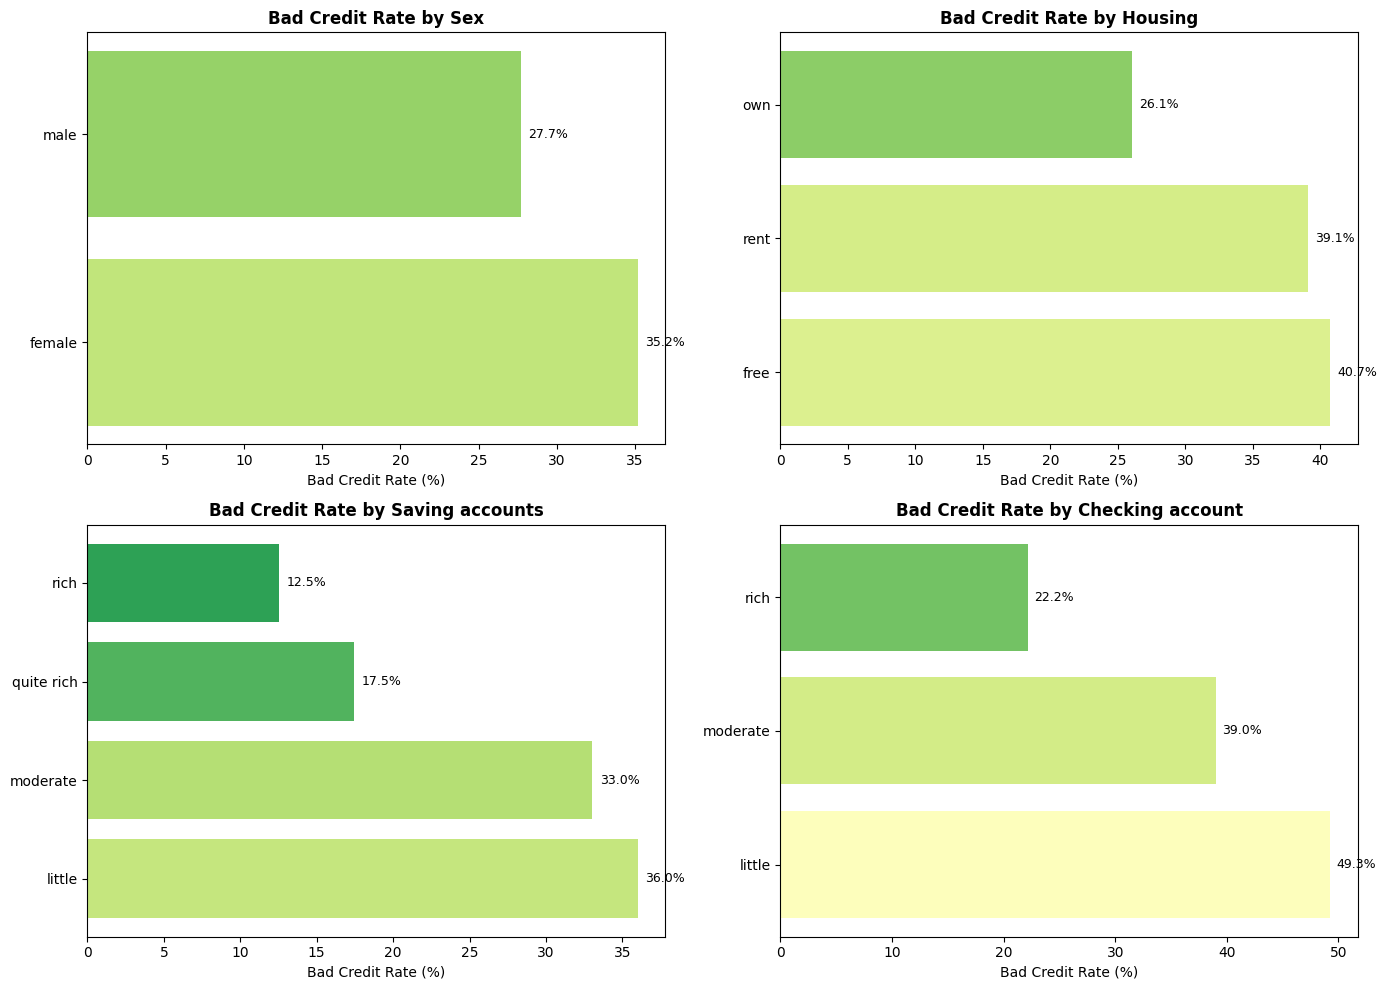

In [27]:
#bad credit rate per categorical feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, CATEGORICAL_FEATURES[:4]):
    rate = df.groupby(col)[TARGET_COL].apply(
        lambda x: (x.str.lower()=='bad').mean()*100
    ).sort_values(ascending=False)
    bars = ax.barh(rate.index, rate.values,
                   color=plt.cm.RdYlGn_r(rate.values/100))
    ax.set_title(f'Bad Credit Rate by {col}', fontweight='bold')
    ax.set_xlabel('Bad Credit Rate (%)')
    for bar, val in zip(bars, rate.values):
        ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/plots/categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Preprocessing Pipeline

In [28]:
#good->0, bad->1
le = LabelEncoder()
df['Risk_encoded'] = le.fit_transform(df[TARGET_COL].str.lower())

X = df.drop([TARGET_COL, 'Risk_encoded'], axis=1)
y = df['Risk_encoded']

# 60/20/20 split with stratification
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=VAL_SIZE, random_state=RANDOM_STATE, stratify=y_temp)

print(f'Train:{len(X_train)} samples')
print(f'Validation:{len(X_val)} samples')
print(f'Test:{len(X_test)} samples')

Train:600 samples
Validation:200 samples
Test:200 samples


In [29]:
#numerical pipeline
numeric_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

#categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#columnTransformer combines both
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, NUMERICAL_FEATURES),
    ('cat', categorical_pipeline, CATEGORICAL_FEATURES)
])

In [30]:
#preprocess-fit only on training data
X_train_pp = preprocessor.fit_transform(X_train)
X_val_pp   = preprocessor.transform(X_val)
X_test_pp  = preprocessor.transform(X_test)

print(f'before SMOTE:{dict(pd.Series(y_train).value_counts())}')

#SMOTE:training data only
smote = SMOTE(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smote.fit_resample(X_train_pp, y_train)

print(f'After SMOTE:{dict(pd.Series(y_train_bal).value_counts())}')
print(f'Training samples:{len(X_train)} -> {len(X_train_bal)}')

before SMOTE:{1: np.int64(420), 0: np.int64(180)}
After SMOTE:{1: np.int64(420), 0: np.int64(420)}
Training samples:600 -> 840


# Model Training & Tuning

In [31]:
from sklearn.metrics import f1_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
}

results = {}
print(f'{'Model':<25} {'Accuracy':>10} {'F1-Score':>10} {'ROC-AUC':>10}')
print('-' * 60)

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_val_pp)
    y_prob = model.predict_proba(X_val_pp)[:, 1]
    acc    = model.score(X_val_pp, y_val)
    f1     = f1_score(y_val, y_pred)
    auc    = roc_auc_score(y_val, y_prob)
    results[name] = { 'model':model, 'accuracy':acc, 'f1':f1, 'roc_auc':auc }
    print(f'{name:<25} {acc:>10.4f} {f1:>10.4f} {auc:>10.4f}')

best_name = max(results, key=lambda x: results[x]['roc_auc'])
print(f'\nBest model by ROC-AUC: {best_name}')

Model                       Accuracy   F1-Score    ROC-AUC
------------------------------------------------------------
Logistic Regression           0.7600     0.8154     0.8083
Random Forest                 0.7100     0.8014     0.7417
Gradient Boosting             0.7450     0.8271     0.7892
SVM                           0.7650     0.8303     0.8043

Best model by ROC-AUC: Logistic Regression


In [32]:
param_grids = {
    'Random Forest': {
        'n_estimators':      [100, 200, 300],
        'max_depth':         [None, 5, 10, 15],
        'min_samples_split': [2, 5, 10],
        'class_weight':      ['balanced', None]
    },
    'Gradient Boosting': {
        'n_estimators':  [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth':     [3, 5, 7],
    },
    'Logistic Regression': {
        'C': [0.001, 0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'], 'solver': ['liblinear']
    },
    'SVM': { 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'] }
}

base_model = models[best_name].__class__(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator  = base_model,
    param_grid = param_grids.get(best_name, {}),
    scoring    = 'roc_auc',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)
grid_search.fit(X_train_bal, y_train_bal)

print(f'Best params: {grid_search.best_params_}')
print(f'Best CV ROC-AUC: {grid_search.best_score_:.4f}')
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV ROC-AUC: 0.7610


# Evaluation & Saving

In [33]:
y_test_pred = best_model.predict(X_test_pp)
y_test_prob = best_model.predict_proba(X_test_pp)[:, 1]

print(f'ROC-AUC: {roc_auc_score(y_test, y_test_prob):.4f}')
print(classification_report(y_test, y_test_pred, target_names=['Good Credit', 'Bad Credit']))


ROC-AUC: 0.7623
              precision    recall  f1-score   support

 Good Credit       0.45      0.75      0.57        60
  Bad Credit       0.85      0.61      0.71       140

    accuracy                           0.66       200
   macro avg       0.65      0.68      0.64       200
weighted avg       0.73      0.66      0.67       200



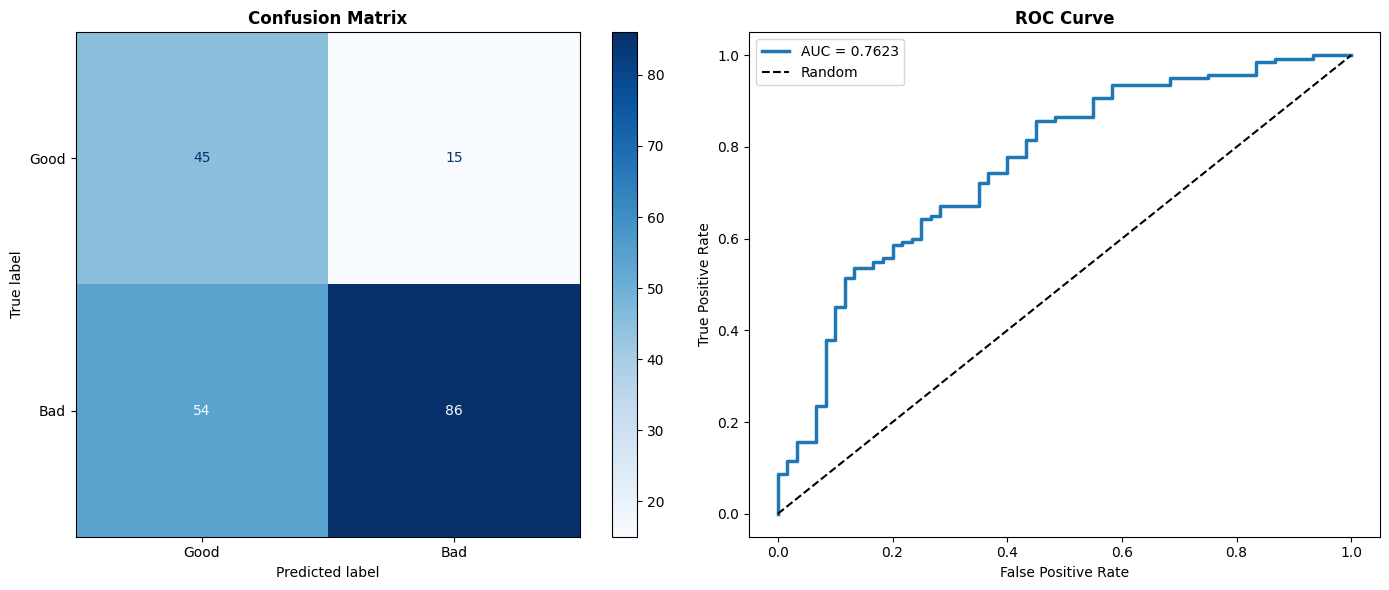

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['Good','Bad']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

#ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
auc = roc_auc_score(y_test, y_test_prob)
axes[1].plot(fpr, tpr, linewidth=2.5, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/plots/final_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
if hasattr(best_model, 'feature_importances_'):
    cat_names = (preprocessor
                 .named_transformers_['cat']
                 .named_steps['onehot']
                 .get_feature_names_out(CATEGORICAL_FEATURES))
    all_names = list(NUMERICAL_FEATURES) + list(cat_names)
    importances = best_model.feature_importances_
    idx = np.argsort(importances)[::-1][:15]

    plt.figure(figsize=(10, 7))
    plt.barh([all_names[i] for i in idx[::-1]], importances[idx[::-1]], color='#2E75B6')
    plt.title('Top 15 Feature Importances', fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/plots/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

In [36]:
import joblib

# Save tooutputs/models/
joblib.dump(preprocessor, 'outputs/models/preprocessor.pkl')
joblib.dump(best_model,   'outputs/models/best_model.pkl')
print('Models saved to outputs/models/')

from google.colab import files
files.download('outputs/models/preprocessor.pkl')
files.download('outputs/models/best_model.pkl')

Models saved to outputs/models/


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>